In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# **Data Exploration**

In [ ]:
df = pd.read_csv ("/content/employee_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/employee_data.csv'

In [ ]:
df.head ()

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,GenderCode,EmployeeStatus,Current Employee Rating
0,3427,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Female,Active,4
1,3428,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Male,Active,3
2,3429,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Male,Active,4
3,3430,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Male,Active,2
4,3431,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Female,Active,3


In [ ]:
df.tail()

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,GenderCode,EmployeeStatus,Current Employee Rating
595,1022,Frederick,Howe,19-Sep-22,NaN,Software Engineer,Nicole Haynes,frederick.howe@bilearner.com,PYZ,Male,Active,3
596,1023,Nickolas,Davila,9-Nov-18,10-Oct-21,Shared Services Manager,Debra Morales,nickolas.davila@bilearner.com,WBL,Male,Active,3
597,1024,Kasey,Boyer,30-Dec-18,23-Jun-21,Shared Services Manager,Chad Andrews,kasey.boyer@bilearner.com,NEL,Female,Active,3
598,1025,Giovanni,Jenkins,11-May-23,15-May-23,Senior BI Developer,John Wallace,giovanni.jenkins@bilearner.com,PL,Female,Active,3
599,1026,Alexis,Moss,3-Nov-22,9-Feb-23,Senior BI Developer,Benjamin Frederick,alexis.moss@bilearner.com,BPC,Female,Active,3


In [ ]:
df.shape

(600, 12)

In [ ]:
df.dtypes

EmpID                       int64
FirstName                  object
LastName                   object
StartDate                  object
ExitDate                   object
Title                      object
Supervisor                 object
ADEmail                    object
BusinessUnit               object
GenderCode                 object
EmployeeStatus             object
Current Employee Rating     int64
dtype: object

In [ ]:
df.columns

Index(['EmpID', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title',
       'Supervisor', 'ADEmail', 'BusinessUnit', 'GenderCode', 'EmployeeStatus',
       'Current Employee Rating'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmpID                    600 non-null    int64 
 1   FirstName                600 non-null    object
 2   LastName                 600 non-null    object
 3   StartDate                600 non-null    object
 4   ExitDate                 322 non-null    object
 5   Title                    600 non-null    object
 6   Supervisor               600 non-null    object
 7   ADEmail                  600 non-null    object
 8   BusinessUnit             600 non-null    object
 9   GenderCode               600 non-null    object
 10  EmployeeStatus           600 non-null    object
 11  Current Employee Rating  600 non-null    int64 
dtypes: int64(2), object(10)
memory usage: 56.4+ KB


In [ ]:
df.describe()

,EmpID,Current Employee Rating
count,600.000000,600.000000
mean,3596.500000,2.938333
std,573.609882,0.905113
min,1001.000000,1.000000
25%,3550.750000,3.000000
50%,3700.500000,3.000000
75%,3850.250000,3.000000
max,4000.000000,5.000000


In [ ]:
print(df[df['LastName'] == 'Bridges'])

     EmpID FirstName LastName  StartDate ExitDate                    Title  \
0     3427     Uriah  Bridges  20-Sep-19      NaN  Production Technician I   
329   3756    Junior  Bridges  24-May-21      NaN  Production Technician I   

            Supervisor                       ADEmail BusinessUnit GenderCode  \
0         Peter Oneill   uriah.bridges@bilearner.com         CCDR     Female   
329  Melissa Hernandez  junior.bridges@bilearner.com          BPC     Female   

    EmployeeStatus  Current Employee Rating  
0           Active                        4  
329         Active                        3  


In [ ]:
print("Value of row 0")
display(df.iloc[0])

Value of row 0


EmpID                                             3427
FirstName                                        Uriah
LastName                                       Bridges
StartDate                                    20-Sep-19
ExitDate                                           NaN
Title                          Production Technician I
Supervisor                                Peter Oneill
ADEmail                    uriah.bridges@bilearner.com
BusinessUnit                                      CCDR
GenderCode                                      Female
EmployeeStatus                                  Active
Current Employee Rating                              4
Name: 0, dtype: object

In [ ]:
print(df['FirstName'].min())
print(df['FirstName'].max())

Aaliyah
Zoie


In [ ]:
print(df['Current Employee Rating'].min())
print(df['Current Employee Rating'].max())

1
5


In [ ]:
df.nunique()

EmpID                      600
FirstName                  508
LastName                   479
StartDate                  520
ExitDate                   274
Title                       20
Supervisor                 599
ADEmail                    600
BusinessUnit                10
GenderCode                   2
EmployeeStatus               5
Current Employee Rating      5
dtype: int64

In [ ]:
for col in df :
  if len(df[col].value_counts()) <= 32:
    print(f'Column: ', col, '\nUnique Values: ', df[col].sort_values().unique(), '\n_____________________________________')

Column:  Title 
Unique Values:  ['Area Sales Manager' 'BI Director' 'CIO' 'Data Analyst' 'Data Analyst '
 'Data Architect' 'Database Administrator' 'Enterprise Architect'
 'IT Support' 'Network Engineer' 'Principal Data Architect'
 'Production Technician I' 'Production Technician II'
 'Senior BI Developer' 'Shared Services Manager' 'Software Engineer'
 'Software Engineering Manager' 'Sr. Accountant' 'Sr. DBA'
 'Sr. Network Engineer'] 
_____________________________________
Column:  BusinessUnit 
Unique Values:  ['BPC' 'CCDR' 'EW' 'MSC' 'NEL' 'PL' 'PYZ' 'SVG' 'TNS' 'WBL'] 
_____________________________________
Column:  GenderCode 
Unique Values:  ['Female' 'Male'] 
_____________________________________
Column:  EmployeeStatus 
Unique Values:  ['Active' 'Future Start' 'Leave of Absence' 'Terminated for Cause'
 'Voluntarily Terminated'] 
_____________________________________
Column:  Current Employee Rating 
Unique Values:  [1 2 3 4 5] 
_____________________________________


In [ ]:
sr_date = df.groupby("StartDate")["StartDate"].value_counts().reset_index(name='Count')
sr_date

,StartDate,Count
0,1-Apr-23,1
1,1-Aug-19,1
2,1-Aug-21,1
3,1-Dec-19,1
4,1-Feb-19,1
...,...,...
515,9-Nov-21,1
516,9-Sep-18,1
517,9-Sep-19,1
518,9-Sep-21,1


In [ ]:
ex_date = df.groupby("ExitDate")["ExitDate"].value_counts().reset_index(name='Count')
ex_date

,ExitDate,Count
0,1-Jan-22,1
1,1-Jul-23,1
2,1-Jun-21,1
3,1-May-21,1
4,1-May-23,3
...,...,...
269,9-Jan-22,1
270,9-Jan-23,1
271,9-Jul-23,2
272,9-Oct-22,1


In [ ]:
emp_rate = df.groupby("Current Employee Rating")["Current Employee Rating"].value_counts().reset_index(name='Count')
emp_rate

,Current Employee Rating,Count
0,1,51
1,2,78
2,3,362
3,4,75
4,5,34


In [ ]:
emp_status = df.groupby("EmployeeStatus")["EmployeeStatus"].value_counts().reset_index(name='Count')
emp_status

,EmployeeStatus,Count
0,Active,469
1,Future Start,47
2,Leave of Absence,17
3,Terminated for Cause,12
4,Voluntarily Terminated,55


In [ ]:
df.isnull().sum()

EmpID                        0
FirstName                    0
LastName                     0
StartDate                    0
ExitDate                   278
Title                        0
Supervisor                   0
ADEmail                      0
BusinessUnit                 0
GenderCode                   0
EmployeeStatus               0
Current Employee Rating      0
dtype: int64

In [ ]:
df.notnull().sum()

EmpID                      600
FirstName                  600
LastName                   600
StartDate                  600
ExitDate                   322
Title                      600
Supervisor                 600
ADEmail                    600
BusinessUnit               600
GenderCode                 600
EmployeeStatus             600
Current Employee Rating    600
dtype: int64

# **Data Preprocessing**

In [ ]:
df.fillna(0)

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,GenderCode,EmployeeStatus,Current Employee Rating
0,3427,Uriah,Bridges,20-Sep-19,0,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Female,Active,4
1,3428,Paula,Small,11-Feb-23,0,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Male,Active,3
2,3429,Edward,Buck,10-Dec-18,0,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Male,Active,4
3,3430,Michael,Riordan,21-Jun-21,0,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Male,Active,2
4,3431,Jasmine,Onque,29-Jun-19,0,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Female,Active,3
...,...,...,...,...,...,...,...,...,...,...,...,...
595,1022,Frederick,Howe,19-Sep-22,0,Software Engineer,Nicole Haynes,frederick.howe@bilearner.com,PYZ,Male,Active,3
596,1023,Nickolas,Davila,9-Nov-18,10-Oct-21,Shared Services Manager,Debra Morales,nickolas.davila@bilearner.com,WBL,Male,Active,3
597,1024,Kasey,Boyer,30-Dec-18,23-Jun-21,Shared Services Manager,Chad Andrews,kasey.boyer@bilearner.com,NEL,Female,Active,3
598,1025,Giovanni,Jenkins,11-May-23,15-May-23,Senior BI Developer,John Wallace,giovanni.jenkins@bilearner.com,PL,Female,Active,3


In [ ]:
df.dropna()

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,GenderCode,EmployeeStatus,Current Employee Rating
6,3433,Latia,Costa,6-Apr-22,3-Jul-23,Area Sales Manager,Jacob Braun,latia.costa@bilearner.com,WBL,Female,Active,4
7,3434,Sharlene,Terry,6-Nov-20,29-Jan-23,Area Sales Manager,Tracy Marquez,sharlene.terry@bilearner.com,CCDR,Female,Active,2
9,3436,Joseph,Martins,21-Jan-22,29-Jun-23,Area Sales Manager,George Jenkins,joseph.martins@bilearner.com,BPC,Male,Active,5
11,3438,Dheepa,Nguyen,10-Aug-18,4-Nov-19,Area Sales Manager,Brian Miller,dheepa.nguyen@bilearner.com,MSC,Female,Active,3
12,3439,Bartholemew,Khemmich,25-May-22,27-Nov-22,Area Sales Manager,Charles Parks,bartholemew.khemmich@bilearner.com,EW,Male,Active,3
...,...,...,...,...,...,...,...,...,...,...,...,...
594,1021,Joe,Fletcher,9-Nov-20,17-Jul-23,Software Engineer,Amanda Hayden,joe.fletcher@bilearner.com,TNS,Male,Voluntarily Terminated,3
596,1023,Nickolas,Davila,9-Nov-18,10-Oct-21,Shared Services Manager,Debra Morales,nickolas.davila@bilearner.com,WBL,Male,Active,3
597,1024,Kasey,Boyer,30-Dec-18,23-Jun-21,Shared Services Manager,Chad Andrews,kasey.boyer@bilearner.com,NEL,Female,Active,3
598,1025,Giovanni,Jenkins,11-May-23,15-May-23,Senior BI Developer,John Wallace,giovanni.jenkins@bilearner.com,PL,Female,Active,3


In [ ]:
df['GenderCode'] = df['GenderCode'].map({'Male': 0 , 'Female':1})

In [ ]:
df['EmployeeStatus'] = df['EmployeeStatus'].map({'Active':	0,'Future Start':	1,'Leave of Absence':	2,'Terminated for Cause': 3,'Voluntarily Terminated': 4})

In [ ]:
print("Duplicates before dropping:")
print(df[df.duplicated()])
df_dropped = df.drop_duplicates()
print("\nAfter dropping duplicates:")
print(df_dropped)

Duplicates before dropping:
Empty DataFrame
Columns: [EmpID, FirstName, LastName, StartDate, ExitDate, Title, Supervisor, ADEmail, BusinessUnit, GenderCode, EmployeeStatus, Current Employee Rating]
Index: []

After dropping duplicates:
     EmpID  FirstName LastName  StartDate   ExitDate                    Title  \
0     3427      Uriah  Bridges  20-Sep-19        NaN  Production Technician I   
1     3428      Paula    Small  11-Feb-23        NaN  Production Technician I   
2     3429     Edward     Buck  10-Dec-18        NaN       Area Sales Manager   
3     3430    Michael  Riordan  21-Jun-21        NaN       Area Sales Manager   
4     3431    Jasmine    Onque  29-Jun-19        NaN       Area Sales Manager   
..     ...        ...      ...        ...        ...                      ...   
595   1022  Frederick     Howe  19-Sep-22        NaN        Software Engineer   
596   1023   Nickolas   Davila   9-Nov-18  10-Oct-21  Shared Services Manager   
597   1024      Kasey    Boyer  30-

In [ ]:
cat_columns = ['FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title',
       'Supervisor', 'ADEmail', 'BusinessUnit' ,'GenderCode' ,'EmployeeStatus']

In [ ]:
le = LabelEncoder()

for col in cat_columns :
    df[col] = le.fit_transform(df[col])

In [ ]:
df.dtypes

EmpID                      int64
FirstName                  int64
LastName                   int64
StartDate                  int64
ExitDate                   int64
Title                      int64
Supervisor                 int64
ADEmail                    int64
BusinessUnit               int64
GenderCode                 int64
EmployeeStatus             int64
Current Employee Rating    int64
dtype: object

In [ ]:
X = df[['EmployeeStatus']]
numerical_cols = [col for col in X.columns if X[col].dtype in ["int64","float64"]]
standard_scaler = StandardScaler()
X[numerical_cols] = standard_scaler.fit_transform(X[numerical_cols])
print(X.head())

   EmployeeStatus
0       -0.455143
1       -0.455143
2       -0.455143
3       -0.455143
4       -0.455143


<ipython-input-59-bb4b4fdaa005>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numerical_cols] = standard_scaler.fit_transform(X[numerical_cols])


In [ ]:
y = df["Current Employee Rating"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [ ]:
model = SVC()
model.fit(X_train, y_train)

SVC()

In [ ]:
accuracy = model.score(X_test, y_test)
print("Test accuracy:", accuracy*100)

Test accuracy: 66.66666666666666


# **Data Visualization**

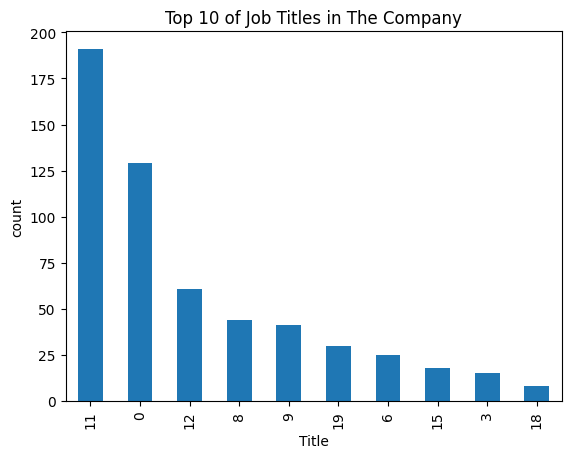

In [ ]:
df.groupby('Title')['EmpID'].count().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 of Job Titles in The Company')
plt.ylabel("count");

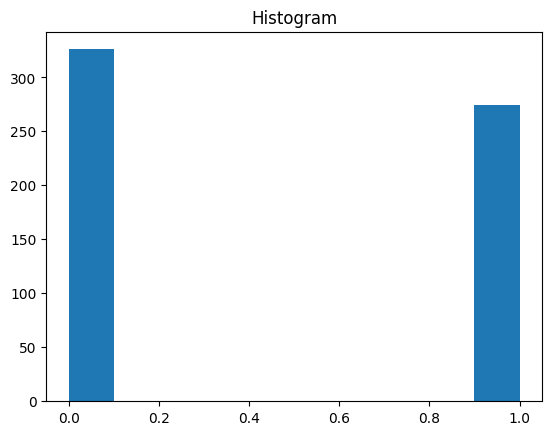

In [ ]:
plt.hist(df["GenderCode"])
plt.title("Histogram")
plt.show()

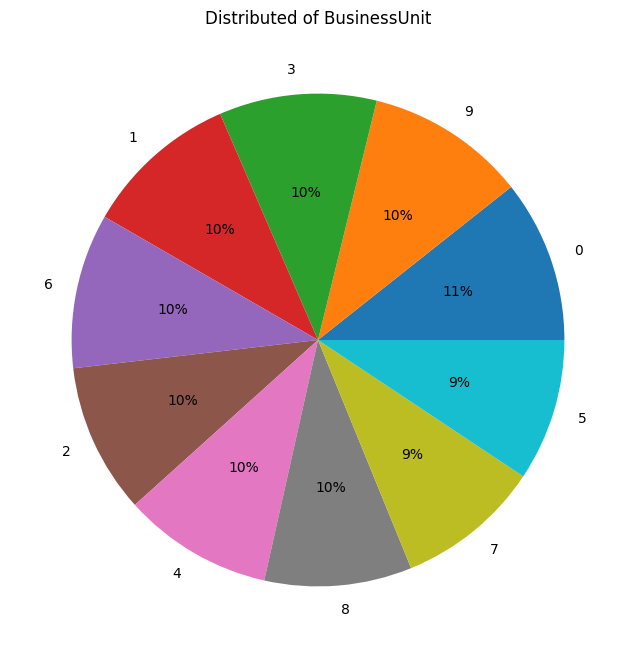

In [ ]:
businessunit_counts = df['BusinessUnit'].value_counts()
plt.figure(figsize=(10,8))
plt.pie(businessunit_counts, labels=businessunit_counts.index, autopct='%1.0f%%')
plt.title("Distributed of BusinessUnit")
plt.show()

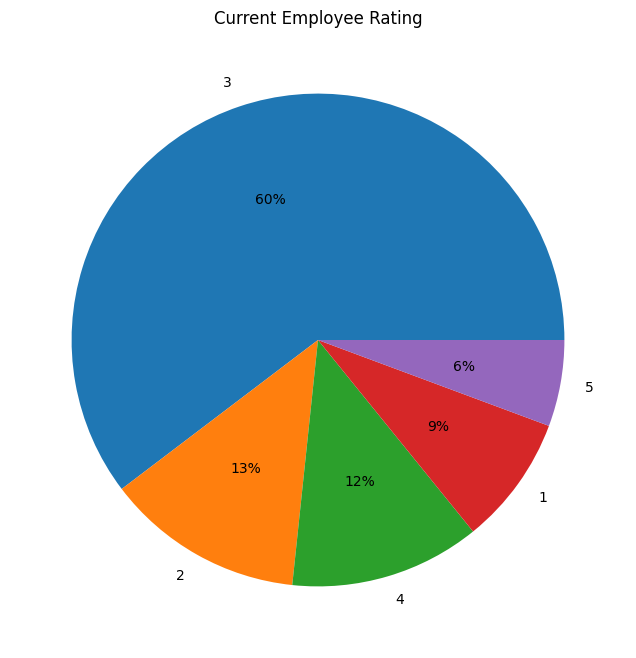

In [ ]:
rate_counts = df['Current Employee Rating'].value_counts()
plt.figure(figsize=(10,8))
plt.pie(rate_counts, labels=rate_counts.index, autopct='%1.0f%%')
plt.title("Current Employee Rating")
plt.show()

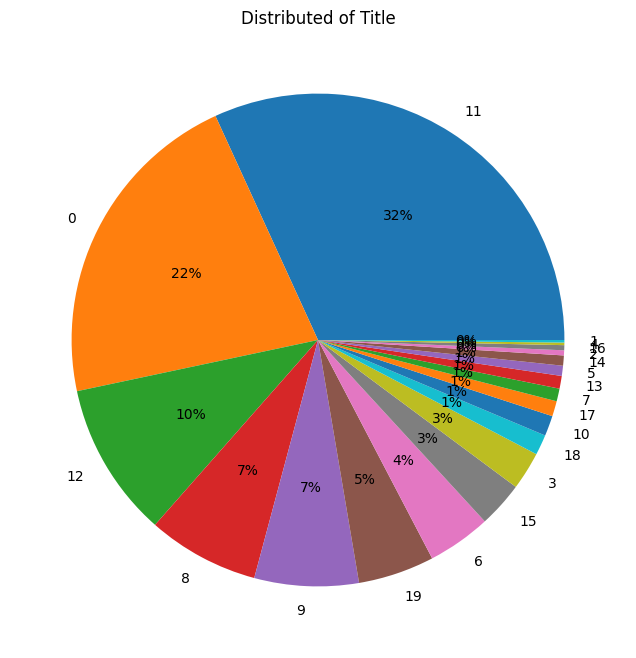

In [ ]:
title_counts = df['Title'].value_counts()
plt.figure(figsize=(10,8))
plt.pie(title_counts, labels=title_counts.index, autopct='%1.0f%%')
plt.title("Distributed of Title")
plt.show()

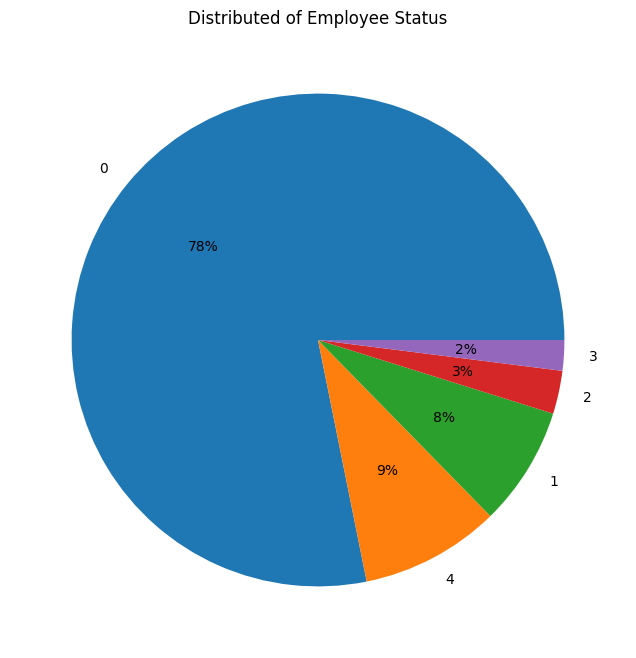

In [ ]:
status_counts = df['EmployeeStatus'].value_counts()
plt.figure(figsize=(10,8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.0f%%')
plt.title("Distributed of Employee Status")
plt.show()

In [ ]:
fig_classification = px.histogram(df, x="Current Employee Rating", color="GenderCode",
                                  title="Distribution of Employee Gender by rating",barmode="group")
fig_classification.update_xaxes(categoryorder="total ascending")
fig_classification.show()

# **Data Modeling**

In [ ]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)
print(f"Accuracy: {accuracy*100}")

Confusion Matrix:
[[ 0  0  5  0  0]
 [ 0  0 10  0  0]
 [ 0  0 40  0  0]
 [ 0  0  2  0  0]
 [ 0  0  3  0  0]]

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00        10
           3       0.67      1.00      0.80        40
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3

    accuracy                           0.67        60
   macro avg       0.13      0.20      0.16        60
weighted avg       0.44      0.67      0.53        60

Accuracy: 66.66666666666666


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



<Axes: >

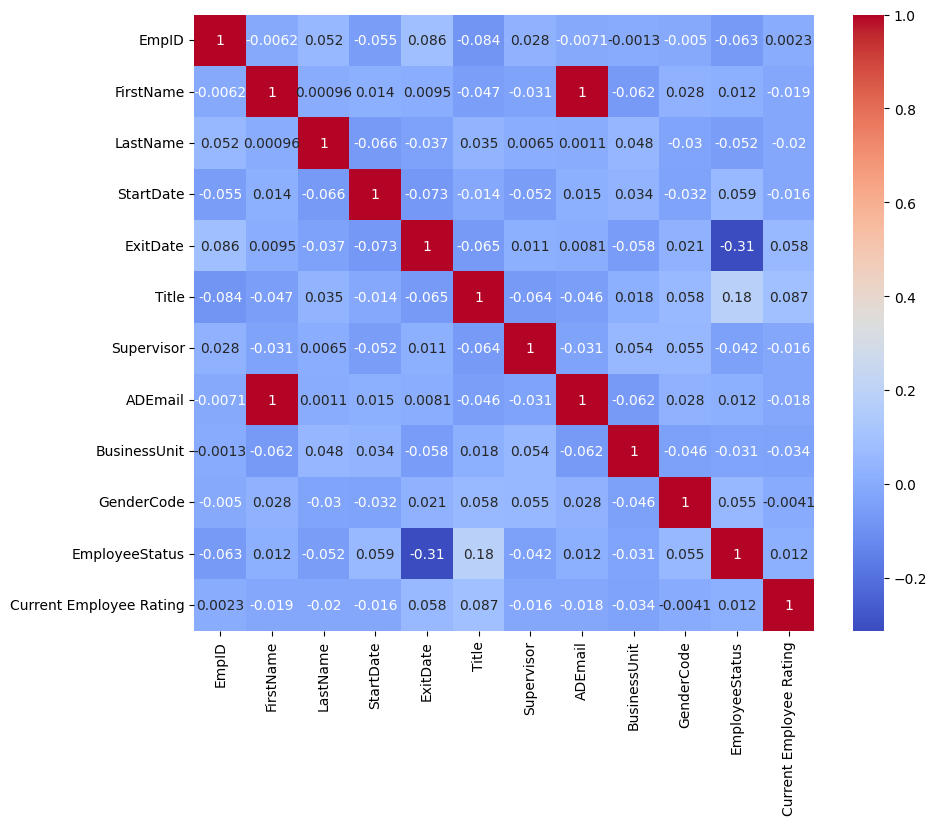

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm' )